# Telco Customer Churn — Modeling

## Goal
Train and compare multiple classification models, handle class imbalance,
evaluate performance and select the best model.

**Models we will compare:**
- Logistic Regression
- Random Forest
- XGBoost
- LightGBM
- Decision Tree

## 1. Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

## 2. Data Preprocessing

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df = df.drop(columns=['customerID'])
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(df['Churn'].value_counts())
print(f"Shape: {df.shape}")

Churn
0    5174
1    1869
Name: count, dtype: int64
Shape: (7043, 20)


In [3]:
# Binary columns
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = (df[col] == 'Yes').astype(int)

# gender
df['gender'] = (df['gender'] == 'Male').astype(int)

# Three-value columns
three_val_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in three_val_cols:
    df[col] = (df[col] == 'Yes').astype(int)

# One-Hot Encoding
df = pd.get_dummies(df, columns=['InternetService', 'Contract', 'PaymentMethod'], drop_first=False)

print(f"Shape after encoding: {df.shape}")

Shape after encoding: (7043, 27)


## 3. Split Features & Target

In [4]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nClass distribution:\n{y.value_counts()}")

X shape: (7043, 26)
y shape: (7043,)

Class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 4. Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

Train size: (5634, 26)
Test size: (1409, 26)

Train class distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Test class distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


## 5. Handle Class Imbalance (SMOTE)

In [6]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


## 6. Train Models

In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'f1': classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'],
        'precision': classification_report(y_test, y_pred, output_dict=True)['1']['precision'],
        'recall': classification_report(y_test, y_pred, output_dict=True)['1']['recall'],
    }
    print(f"{name} trained ")

Logistic Regression trained 
Decision Tree trained 
Random Forest trained 
XGBoost trained 
LightGBM trained 


## 7. Model Comparison

In [8]:
comparison = pd.DataFrame({
    name: {
        'ROC-AUC': round(v['roc_auc'], 4),
        'F1': round(v['f1'], 4),
        'Precision': round(v['precision'], 4),
        'Recall': round(v['recall'], 4),
    }
    for name, v in results.items()
}).T.sort_values('ROC-AUC', ascending=False)

print(comparison)

                     ROC-AUC      F1  Precision  Recall
LightGBM              0.8382  0.5987     0.5857  0.6123
Logistic Regression   0.8348  0.6081     0.5801  0.6390
Random Forest         0.8267  0.5928     0.5920  0.5936
XGBoost               0.8218  0.5969     0.5846  0.6096
Decision Tree         0.6498  0.4870     0.4746  0.5000


## 8. ROC Curves

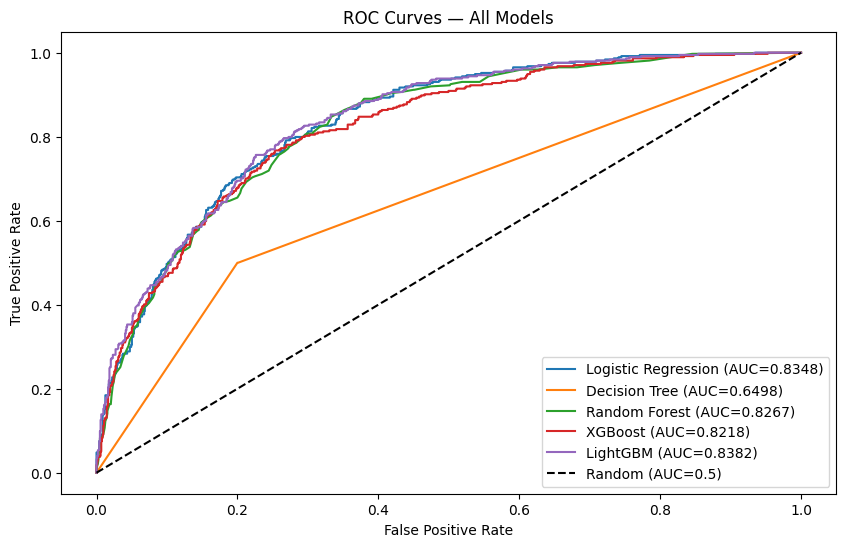

In [9]:
plt.figure(figsize=(10, 6))

for name, v in results.items():
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={v['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.savefig('../reports/figures/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Confusion Matrix

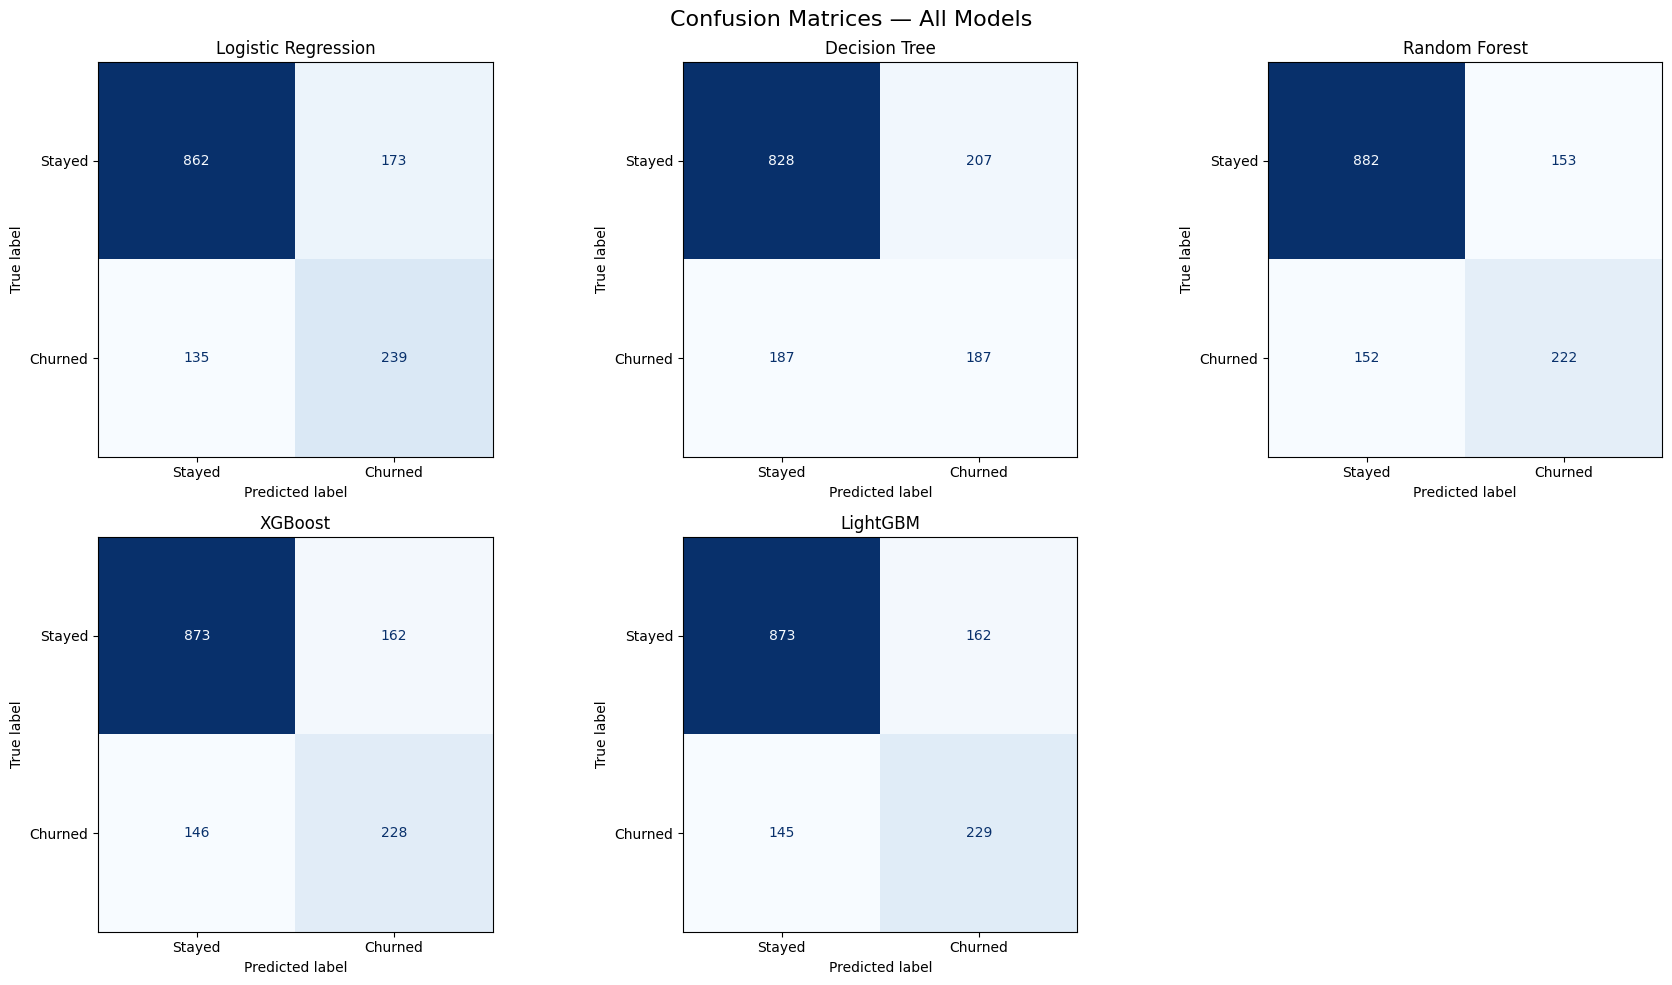

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, v) in enumerate(results.items()):
    cm = confusion_matrix(y_test, v['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}')

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices — All Models', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Conclusions

- Best model by ROC-AUC: **LightGBM (0.8382)**
- Best model by Recall: **Logistic Regression (0.6390)** — catches more churners
- **Decision Tree** performed worst (AUC=0.6498) — overfitting on single tree
- LightGBM missed only **145 churners** (FN) — best for business
- Selected model for SHAP analysis: **LightGBM**